**Data Cleaning**

Data Cleaning plays a significant role in machine learning. Data Cleaning is a process of removing or modifying unnecessary data like redundant data, incomplete information, irrelevant data from a dataset. These type of data harm to a machine learning algorithm. So, It’s better to clean these data to make it better using several techniques. 

Data Cleaning is not just detecting the bad data and removing it from the dataset, but also correcting the bad data and get better results. Data Correcting is itself is a very challenging task. The main goal of the Data Cleaning is to make data standardize and consistent to allow Machine Learning algorithm to analyze data easily.

In this kernel, I have demonstrated how to find noisy data from the dataset.

Let's Load Package

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pylab as plt
import os

In [2]:
train = pd.read_csv('../input/train.csv')
test = pd.read_csv('../input/test.csv')

train.shape,test.shape

((1460, 81), (1459, 80))

## Let's see all basement releated information and find outlier

Here, is the description of the basement related columns

BsmtQual: Evaluates the height of the basement
	
BsmtCond: Evaluates the general condition of the basement
	
BsmtExposure: Refers to walkout or garden level walls
	
BsmtFinType1: Rating of basement finished area
		
BsmtFinSF1: Type 1 finished square feet

BsmtFinType2: Rating of basement finished area (if multiple types)

BsmtFinSF2: Type 2 finished square feet

BsmtUnfSF: Unfinished square feet of basement area

TotalBsmtSF: Total square feet of basement area

In [3]:
basement_columns = ['BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
                    'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF']

In [4]:
basement_missing_df = pd.DataFrame(columns=['train','test'], index=basement_columns)

In [5]:
for e in basement_columns:
    basement_missing_df.loc[e]['train'] = train[e].isna().sum()
    basement_missing_df.loc[e]['test'] = test[e].isna().sum()

In [6]:
basement_missing_df

,train,test
BsmtQual,37,44
BsmtCond,37,45
BsmtExposure,38,44
BsmtFinType1,37,42
BsmtFinSF1,0,1
BsmtFinType2,38,42
BsmtFinSF2,0,1
BsmtUnfSF,0,1
TotalBsmtSF,0,1


## Analysis

As described in data description file, these ['BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1','BsmtFinType2'] columns contain NA values which indicate No Basement.

NA  --> No Basement

let's see the missing value (or NA value) of column BsmtQual and BsmtCond.

**BsmtQual: Evaluates the height of the basement

       Ex	Excellent (100+ inches)	
       Gd	Good (90-99 inches)
       TA	Typical (80-89 inches)
       Fa	Fair (70-79 inches)
       Po	Poor (<70 inches
       NA	No Basement
		
BsmtCond: Evaluates the general condition of the basement

       Ex	Excellent
       Gd	Good
       TA	Typical - slight dampness allowed
       Fa	Fair - dampness or some cracking or settling
       Po	Poor - Severe cracking, settling, or wetness
       NA	No Basement

Let's see the distribution of BsmtQual and BsmtCond feature.

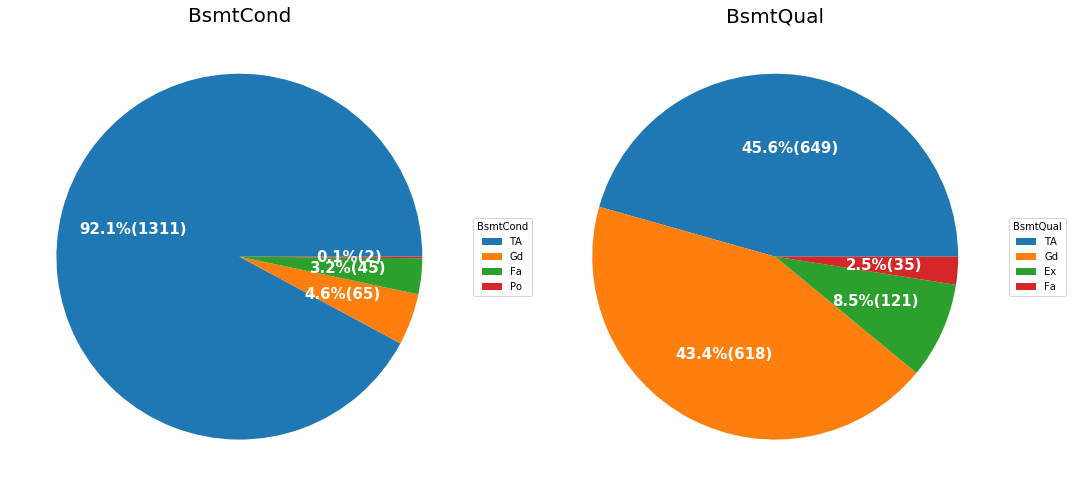

In [7]:
def draw_graph(df, variables, n_rows, n_cols):
    fig=plt.figure(figsize=(15,50))
    for i, var_name in enumerate(variables):
        ax=fig.add_subplot(n_rows,n_cols,i+1)
                
        ingredients = df[var_name].value_counts().index
        data = df[var_name].value_counts().values
        
        def func(pct, allvals):
            total = sum(allvals)
            val = int(round(pct*total/100.0))
            return "{:.1f}%({:d})".format(pct, val)


        wedges, texts, autotexts = ax.pie(data, autopct=lambda pct: func(pct, data),
                                          textprops=dict(color="w"))
        ax.legend(wedges, ingredients,
          title=var_name,
          loc="center left",
          bbox_to_anchor=(1, 0, 0.5, 1))
        plt.setp(autotexts, size=15, weight="bold")

        ax.set_title(var_name, fontsize = 20)
        ax.tick_params(axis = 'both', which = 'major', labelsize = 35)
        ax.tick_params(axis = 'both', which = 'minor', labelsize = 35)
        ax.set_xlabel('')
    fig.tight_layout(rect = [0, 0.03, 1, 0.95])  # Improves appearance a bit.
    plt.show()
    
draw_graph(train, ['BsmtCond','BsmtQual'], 1, 2)

In [8]:
print("NA (no basement) values in train set of BsmtQual:",train['BsmtQual'].isna().sum())
print("NA (no basement) values in test set of BsmtQual :",test['BsmtQual'].isna().sum())
print("******************************************************")
print("NA (no basement) values in train set of BsmtCond:",train['BsmtCond'].isna().sum())
print("NA (no basement) values in test set of BsmtCond :",test['BsmtCond'].isna().sum())

NA (no basement) values in train set of BsmtQual: 37
NA (no basement) values in test set of BsmtQual : 44
******************************************************
NA (no basement) values in train set of BsmtCond: 37
NA (no basement) values in test set of BsmtCond : 45


In train data, columns BsmtQual and BsmtCond both have same number of NA (no basement) values.
but, test data have one more NA (no basement) value in BsmtCond column then BsmtQual.

In test data...BsmtQual feature says , there are only 44 houses with no basement, and
BsmtCond feature says, there are only 45 houses with no basement.

So here is the conflict with the data. So we have to resolve this conflict.

## Let's count the house which have no basement in train & test

In [9]:
no_basement_train_cnt = len(train.loc[(train['BsmtCond'].isna()) & (train['BsmtQual'].isna())])
no_basement_test_cnt = len(test.loc[(test['BsmtCond'].isna()) & (test['BsmtQual'].isna())])

In [10]:
print("The house which have no basement in train : ",no_basement_train_cnt)
print("The house which have no basement in test  : ",no_basement_test_cnt)

The house which have no basement in train :  37
The house which have no basement in test  :  42


Let's see the house which indicate basement in BsmtCond feature but indicate no basement in BsmtQual feature.

In [11]:
test[['Id','BsmtQual','BsmtCond']].loc[(test['BsmtQual'].isna()) & (~test['BsmtCond'].isna())]

,Id,BsmtQual,BsmtCond
757,2218,NaN,Fa
758,2219,NaN,TA


Here, there should be some value in BsmtQual column instead of NaN.
So, these 2 rows are outlier.

Let's see the house which indicate basement in BsmtQual feature, but indicate no basement in BsmtCond feature.

In [12]:
test[['Id','BsmtQual','BsmtCond']].loc[(test['BsmtCond'].isna()) & (~test['BsmtQual'].isna())]

,Id,BsmtQual,BsmtCond
580,2041,Gd,NaN
725,2186,TA,NaN
1064,2525,TA,NaN


Here, there should be some value in BsmtCond column instead of NaN.
So, these three rows are outlier.

Outlier Fetected!!!

Now, Our task is best imputation for these outlier. 

## Let's check other columns related to basements.
## Next Fetaure : BsmtExposure


BsmtExposure: Refers to walkout or garden level walls

       Gd	Good Exposure
       Av	Average Exposure (split levels or foyers typically score average or above)	
       Mn	Mimimum Exposure
       No	No Exposure
       NA	No Basement

In [13]:
print("NA (no basement) values in train set of BsmtExposure:",train['BsmtExposure'].isna().sum())
print("NA (no basement) values in test set of BsmtExposure :",test['BsmtExposure'].isna().sum())

NA (no basement) values in train set of BsmtExposure: 38
NA (no basement) values in test set of BsmtExposure : 44


# Great!! one more outlier detected in train & test

Using two feature BsmtQual and BsmtCond in train dataset, we can conclude that there are only 37 houses which have no basement. And there are only 42 houses which have no basement.

But, we got one more NA(no basement) value in BsmtExposure feature in train set.

Let's see the house in train data which indicate basement in BsmtQual and BsmtCond features, but indicate no basement in BsmtExposure feature.

In [14]:
train[['Id','BsmtQual','BsmtCond','BsmtExposure']].loc[(train['BsmtExposure'].isna()) & (~train['BsmtQual'].isna())]

,Id,BsmtQual,BsmtCond,BsmtExposure
948,949,Gd,TA,NaN


Ooh..It's not possible. 
what you think this house has basement or not? If it has basement, NaN value not possible for BsmtExposure feature.

What's best value you are going to substitute to this outlier?

Let's consider empty value to No Exposure.

In [15]:
train['BsmtExposure'].iloc[948] = 'No'

/opt/conda/lib/python3.6/site-packages/pandas/core/indexing.py:189: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/indexing.html#indexing-view-versus-copy
  self._setitem_with_indexer(indexer, value)


Let's check in test data.. Is their any outlier exist in BsmtExposure feature in testdata?

Let's see the house in test data which indicate basement in BsmtQual and BsmtCond features, but indicate no basement in BsmtExposure feature.

In [16]:
test[['Id','BsmtQual','BsmtCond','BsmtExposure']].loc[(test['BsmtExposure'].isna()) & (~test['BsmtCond'].isna()) & (~test['BsmtQual'].isna())]

,Id,BsmtQual,BsmtCond,BsmtExposure
27,1488,Gd,TA,NaN
888,2349,Gd,TA,NaN


Ohh!!
two wrong missing value detected in testdata in column BsmtExposure.

Let's fill empty value to 'No' as No Exposure

In [17]:
test['BsmtExposure'].iloc[27] = 'No'
test['BsmtExposure'].iloc[888] = 'No'

## Next Feature: TotalBsmtSF (Total square feet of basement area)

Let's check any missing value present in TotalBsmtSF feature

In [18]:
print("Missing value in train set of TotalBsmtSF:",train['TotalBsmtSF'].isna().sum())
print("Missing value in test set of TotalBsmtSF :",test['TotalBsmtSF'].isna().sum())

Missing value in train set of TotalBsmtSF: 0
Missing value in test set of TotalBsmtSF : 1


interesting!! one missing value found in test data. Let's find it

In [19]:
test[basement_columns].loc[test['TotalBsmtSF'].isna()]

,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF
660,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Great.. This house has no basemant as basement related each feature contain null values.

Let's fill the features of this house with appropriate values

In [20]:
test['BsmtQual'].iloc[660] = 'NA'
test['BsmtCond'].iloc[660] = 'NA'
test['BsmtExposure'].iloc[660] = 'NA'
test['BsmtFinType1'].iloc[660] = 'NA'
test['BsmtFinSF1'].iloc[660] = 0
test['BsmtFinType2'].iloc[660] = 'NA'
test['BsmtFinSF2'].iloc[660] = 0
test['BsmtUnfSF'].iloc[660] = 0
test['TotalBsmtSF'].iloc[660] =  0

In [21]:
test[basement_columns].iloc[660]

BsmtQual        NA
BsmtCond        NA
BsmtExposure    NA
BsmtFinType1    NA
BsmtFinSF1       0
BsmtFinType2    NA
BsmtFinSF2       0
BsmtUnfSF        0
TotalBsmtSF      0
Name: 660, dtype: object

Let's check the houses who have zero basement area.

0 basement area ---> means "no basement" right?

In [22]:
print("No basement in train set of TotalBsmtSF:",(train['TotalBsmtSF']==0).sum())
print("No basement in test set of TotalBsmtSF :",(test['TotalBsmtSF']==0).sum())

No basement in train set of TotalBsmtSF: 37
No basement in test set of TotalBsmtSF : 42


Great.. No Outlier.
This feature TotalBsmtSF indicate the same number of houses with no basement.

# Next Feature: BsmtFinType1  & BsmtFinSF1

BsmtFinType1: Rating of basement finished area

       GLQ	Good Living Quarters
       ALQ	Average Living Quarters
       BLQ	Below Average Living Quarters	
       Rec	Average Rec Room
       LwQ	Low Quality
       Unf	Unfinshed
       NA	No Basement

BsmtFinSF1: Type 1 finished square feet

O square feet ---> means no basement-type1 finished area

In [23]:
print("NA (no basement-type 1) houses in train set of BsmtFinType1:",train['BsmtFinType1'].isna().sum())
print("NA (no basement- type1) houses in test set of BsmtFinType1 :",test['BsmtFinType1'].isna().sum())
print("***************************************************")
print("Null values in train set of BsmtFinSF1:",train['BsmtFinSF1'].isna().sum())
print("Null values in test set of BsmtFinSF1 :",test['BsmtFinSF1'].isna().sum())
print("****************************************************")
print("no basement-type1 houses in train set of BsmtFinSF1:", (train['BsmtFinSF1'] == 0).sum())
print("no basement-type1 houses in test set of BsmtFinSF1 :",(test['BsmtFinSF1'] == 0).sum())

NA (no basement-type 1) houses in train set of BsmtFinType1: 37
NA (no basement- type1) houses in test set of BsmtFinType1 : 41
***************************************************
Null values in train set of BsmtFinSF1: 0
Null values in test set of BsmtFinSF1 : 0
****************************************************
no basement-type1 houses in train set of BsmtFinSF1: 467
no basement-type1 houses in test set of BsmtFinSF1 : 463


Let's check outlier!!

Let's see the houses which doesn't have basement-type1 and have area for basement-type1.

In [24]:
train[basement_columns].loc[(train['BsmtFinType1'].isna()) & (train['BsmtFinSF1']!=0)]

,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF


No Outlier..

# Next Feature : BsmtFinType2 & BsmtFinSF2

BsmtFinType2: Rating of basement finished area (if multiple types)

       GLQ	Good Living Quarters
       ALQ	Average Living Quarters
       BLQ	Below Average Living Quarters	
       Rec	Average Rec Room
       LwQ	Low Quality
       Unf	Unfinshed
       NA	No Basement

BsmtFinSF2: Type 2 finished square feet

O square feet ---> means no basement-type2 finished area

In [25]:
print("NA (no basement - type2) houses in train set of BsmtFinType2:",train['BsmtFinType2'].isna().sum())
print("NA (no basement -type2) houses in test set of BsmtFinType2 :",test['BsmtFinType2'].isna().sum())
print("***************************************************")
print("Null values in train set of BsmtFinSF2:",train['BsmtFinSF2'].isna().sum())
print("Null values in test set of BsmtFinSF2 :",test['BsmtFinSF2'].isna().sum())
print("****************************************************")
print("no basement-type2 houses in train set of BsmtFinSF2:", (train['BsmtFinSF2'] == 0).sum())
print("no basement-type2 houses in test set of BsmtFinSF2 :",(test['BsmtFinSF2'] == 0).sum())

NA (no basement - type2) houses in train set of BsmtFinType2: 38
NA (no basement -type2) houses in test set of BsmtFinType2 : 41
***************************************************
Null values in train set of BsmtFinSF2: 0
Null values in test set of BsmtFinSF2 : 0
****************************************************
no basement-type2 houses in train set of BsmtFinSF2: 1293
no basement-type2 houses in test set of BsmtFinSF2 : 1279


Let's check outlier!!

Let's see the houses which doesn't have basement-type2 and have area for basement-type2.


In [26]:
train[basement_columns].loc[(train['BsmtFinType2'].isna()) & (train['BsmtFinSF2']!=0)]

,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF
332,Gd,TA,No,GLQ,1124,NaN,479,1603,3206


Above result show that, 
this house has NaN value in BsmtFinType2 feature however BsmtFinSF2(type2 finished area) has 479 sq.ft area.

So, it's Outlier.

# Next Feature BsmtUnfSF: Unfinished square feet of basement area

In [27]:
print("Null values in train set of BsmtUnfSF:",train['BsmtUnfSF'].isna().sum())
print("Null values in test set of BsmtUnfSF :",test['BsmtUnfSF'].isna().sum())
print("****************************************************")
print("No unfinished basement houses in train set of BsmtUnfSF:", (train['BsmtUnfSF'] == 0).sum())
print("No unfinished basement houses in test set of BsmtUnfSF :",(test['BsmtUnfSF'] == 0).sum())

Null values in train set of BsmtUnfSF: 0
Null values in test set of BsmtUnfSF : 0
****************************************************
No unfinished basement houses in train set of BsmtUnfSF: 118
No unfinished basement houses in test set of BsmtUnfSF : 124


No helpful information found!!

Analysis of basement related features is completed. There is also such kind of ambiguities preset in Garage related features. Next will do an analysis of Garage related features. 

** More to come! Stay tuned, and thanks for reading. :) **


If you find this kernel helpful, please upvote it. 